In [ ]:
### EMOTION DETECTION FROM FACIAL IMAGES USING CNN
### Created by Bareera Mushthak

## Required libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Dataset uploading
from google.colab import files
uploaded = files.upload()
import zipfile
zip_ref =zipfile.ZipFile('Dataset.zip','r')
zip_ref.extractall('content/emotion_data')
zip_ref.close()

## Create train and validation dataset
datagen = ImageDataGenerator(rescale=1./255)
train_data = datagen.flow_from_directory(
    'content/emotion_data/train',
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',

)
val_data = datagen.flow_from_directory(
    'content/emotion_data/test',
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=64,
    class_mode='categorical',
    shuffle=False,
)
# Display number of classes and their names
num_classes= train_data.class_indices
print("Number of classes",num_classes)
print("Class names:", list(train_data.class_indices.keys()))
# show number of samples
print("Number of samples in training set:", train_data.samples)
print("Number of samples in validation set:", val_data.samples)
print(train_data.num_classes)


Number of classes {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of samples in training set: 28709
Number of samples in validation set: 7178
7


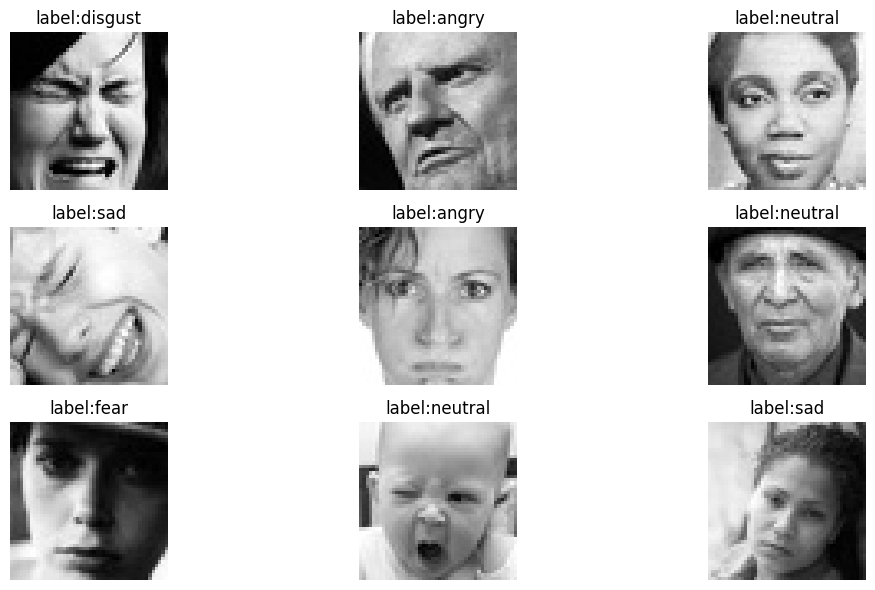

In [ ]:
# Display some sample images
class_names= {v: k for k,v in train_data.class_indices.items()}
images, labels = next(train_data)
plt.figure (figsize=(12,6))
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.imshow(images[i].squeeze(),cmap='gray')
  label_index=np.argmax(labels[i])
  label_name=class_names[label_index]
  plt.title(f"label:{label_name}")
  plt.axis('off')
plt.tight_layout()
plt.savefig('sample_images.png')
plt.show()


In [ ]:
## Build the model
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(48,48,1)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes,activation='softmax')
])

##Compile and train the model
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
# To insert earlystoppings
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
early_stop=EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
#reduce learning rate if loss plateaus
reduce_lr= ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1, min_lr=0.00001)
history=model.fit(train_data,epochs=50,validation_data=val_data, callbacks=[early_stop, reduce_lr])
model.save('emotion_detection_model.h5')


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


449/449 ━━━━━━━━━━━━━━━━━━━━ 167s 364ms/step - accuracy: 0.2690 - loss: 1.9618 - val_accuracy: 0.3593 - val_loss: 1.6674 - learning_rate: 0.0010
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 160s 356ms/step - accuracy: 0.3899 - loss: 1.5530 - val_accuracy: 0.4546 - val_loss: 1.4251 - learning_rate: 0.0010
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 154s 344ms/step - accuracy: 0.4320 - loss: 1.4444 - val_accuracy: 0.4595 - val_loss: 1.4044 - learning_rate: 0.0010
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 143s 318ms/step - accuracy: 0.4733 - loss: 1.3575 - val_accuracy: 0.4674 - val_loss: 1.3975 - learning_rate: 0.0010
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 142s 316ms/step - accuracy: 0.4963 - loss: 1.2942 - val_accuracy: 0.4713 - val_loss: 1.3591 - learning_rate: 0.0010
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 149s 331ms/step - accuracy: 0.5192 - loss: 1.2325 - val_accuracy: 0.5181 - val_loss: 1.2656 - learning_rate: 0.0010
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 238s 412ms/step - accuracy: 0.5495 

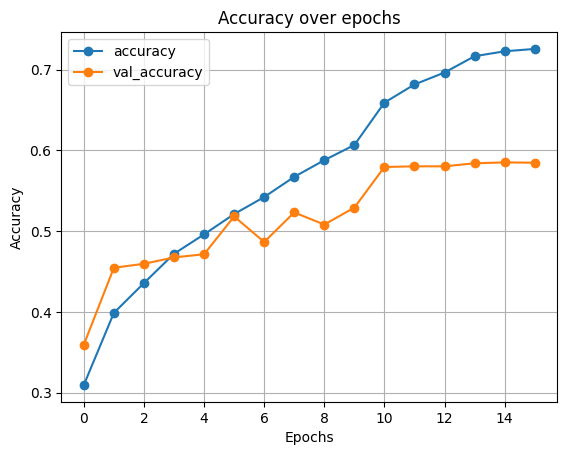

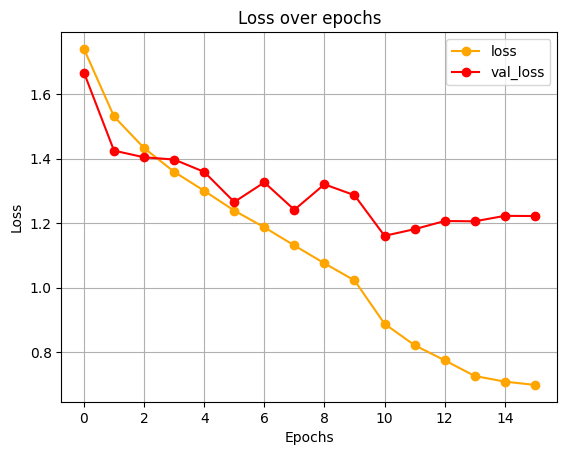

In [ ]:
## Evaluate and visualize metrics
import pandas as pd
# converting history to data frame
history_df=pd.DataFrame(history.history)

#plot training vs validation accuracy and loss
history_df[['accuracy','val_accuracy']].plot(marker='o')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True)
plt.savefig('accuracy over epochs.png')
plt.show()
history_df[['loss','val_loss']].plot(marker='o', color=['orange','red'])
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig('loss over epochs.png')
plt.show()


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
2/2 ━━━━━━━

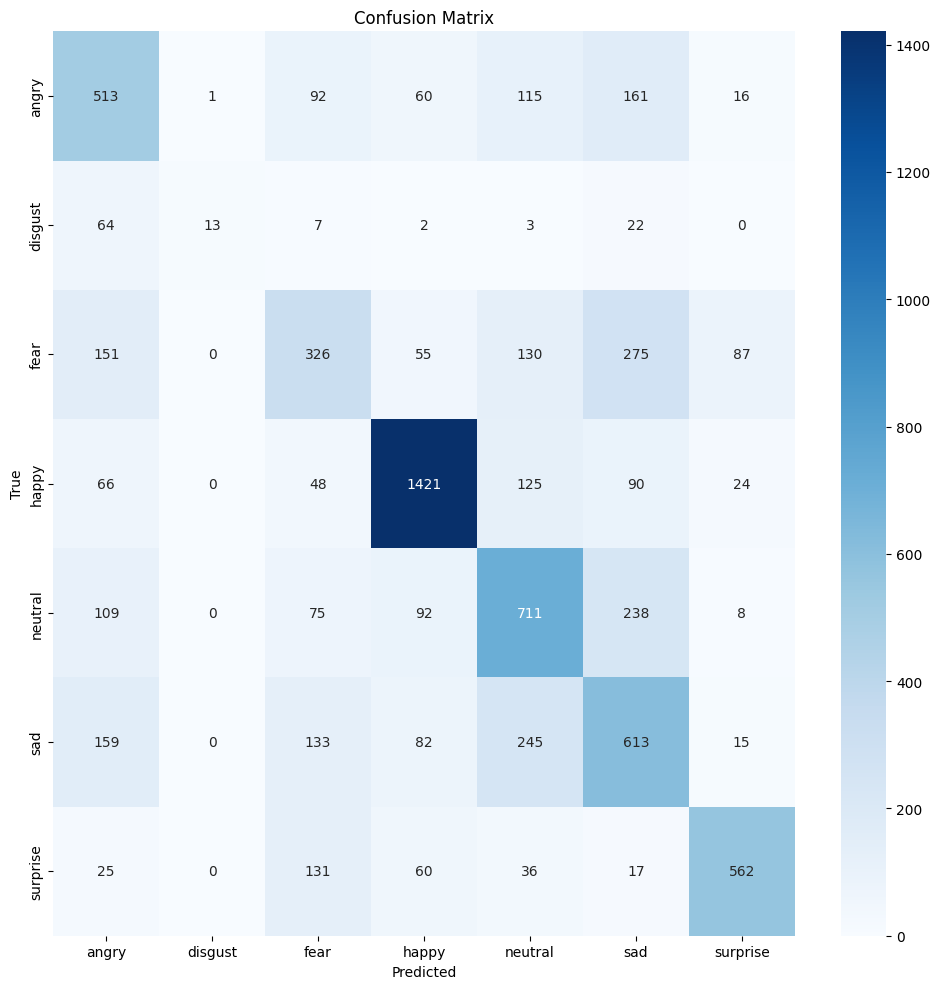

              precision    recall  f1-score   support

       angry       0.47      0.54      0.50       958
     disgust       0.93      0.12      0.21       111
        fear       0.40      0.32      0.36      1024
       happy       0.80      0.80      0.80      1774
     neutral       0.52      0.58      0.55      1233
         sad       0.43      0.49      0.46      1247
    surprise       0.79      0.68      0.73       831

    accuracy                           0.58      7178
   macro avg       0.62      0.50      0.51      7178
weighted avg       0.59      0.58      0.58      7178



In [ ]:
## Confusion Matrix and Report
 # Get true and predicted labels
y_pred=[]
y_true=[]

for images, labels in val_data:
  predictions=model.predict(images)
  y_pred.extend(np.argmax(predictions,axis=1))
  y_true.extend(np.argmax(labels,axis=1))

  if len(y_pred) >= val_data.samples:
    break
# Create confusion matrix
cm= confusion_matrix(y_true,y_pred)
# Plot confusion matrix
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=val_data.class_indices.keys(),yticklabels=val_data.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

print(classification_report(y_true,y_pred,target_names=val_data.class_indices.keys()))


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


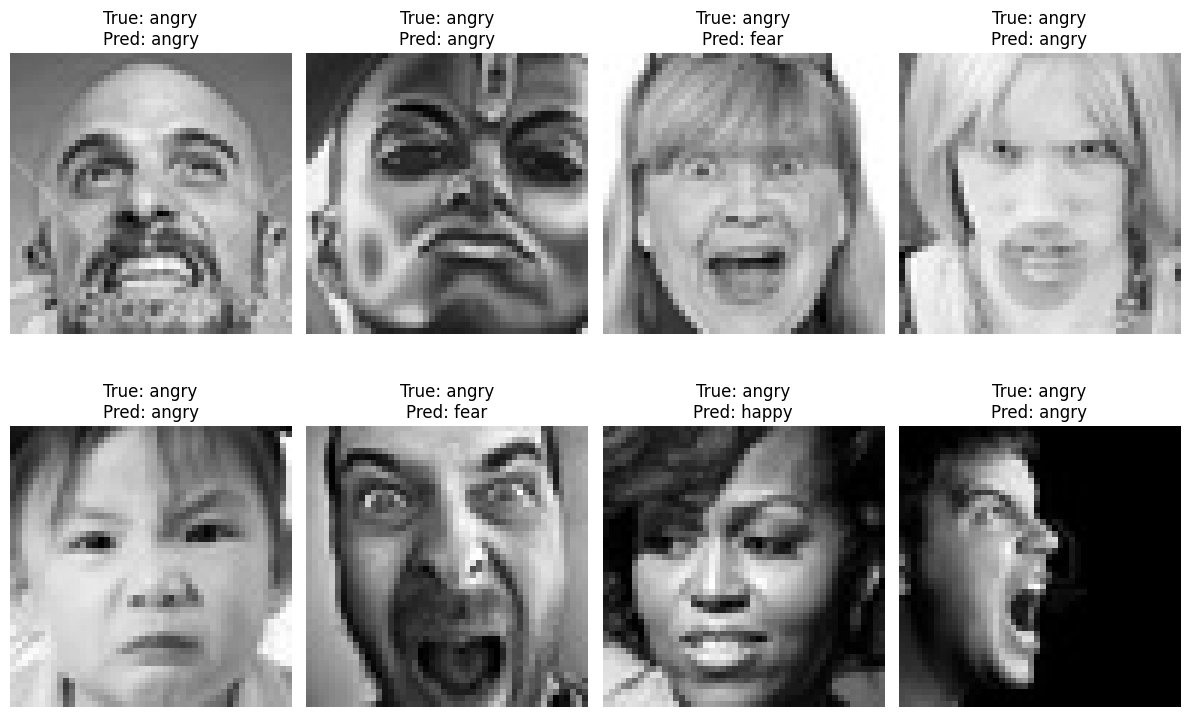

In [ ]:
# # Get one batch from the validation generator
images, labels = next(val_data)  # val_data is an instance of ImageDataGenerator.flow_from_directory

# Predict
predictions = model.predict(images)
predicted_labels = np.argmax(predictions, axis=1)
true_labels=np.argmax(labels,axis=1)

# Class names (update this with your class folder names)
class_names = val_data.class_indices
class_names = {v: k for k, v in class_names.items()}  # Reverse mapping

# Show sample predictions
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
for i in range(8):
    ax = plt.subplot(2, 4, i + 1)
    plt.imshow((images[i]*255).astype("uint8").squeeze(), cmap='gray')  # squeeze if grayscale
    true_label = class_names[true_labels[i]]
    pred_label = class_names[predicted_labels[i]]
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.savefig('sample_predictions.png')
plt.show()